
# Alpha Factor Evaluation

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
%matplotlib inline

import os
import sys
from time import time

from pathlib import Path
import numpy as np
import pandas as pd
import pandas_datareader.data as web

import statsmodels.api as sm
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import scale
import lightgbm as lgb
from scipy.stats import spearmanr
from tqdm import tqdm
import shap

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sys.path.insert(1, "c:\\Users\\paxto\\machine-learning-for-trading")
from utils import MultipleTimeSeriesCV

In [4]:
sns.set_style("whitegrid")
idx = pd.IndexSlice
deciles = np.arange(0.1, 1, 0.1).round(1)

In [5]:
results_path = Path("results")
if not results_path.exists():
    results_path.mkdir()

## Load Data

In [6]:
factors = (
    pd.concat(
        [
            pd.read_hdf("data.h5", "factors/common"),
            pd.read_hdf("data.h5", "factors/formulaic").rename(
                columns=lambda x: f"alpha_{int(x):03}"
            ),
        ],
        axis=1,
    )
    .dropna(axis=1, thresh=100000)
    .sort_index()
)

In [7]:
factors.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1255093 entries, ('A', Timestamp('2007-01-04 00:00:00')) to ('ZION', Timestamp('2016-12-29 00:00:00'))
Columns: 135 entries, sector to alpha_101
dtypes: float64(123), int64(12)
memory usage: 1.3+ GB


In [8]:
fwd_returns = factors.filter(like="fwd").columns
features = factors.columns.difference(fwd_returns).tolist()
alphas = pd.Index([f for f in features if f.startswith("alpha")])

In [9]:
features

['AARONOSC',
 'AD',
 'ADOSC',
 'ADX',
 'ADXR',
 'ALPHA_21',
 'ALPHA_252',
 'ALPHA_63',
 'ATR',
 'BB_LOW',
 'BB_SQUEEZE',
 'BB_UP',
 'BOP',
 'CCI',
 'CMA_21',
 'CMA_252',
 'CMA_63',
 'HML_21',
 'HML_252',
 'HML_63',
 'HT',
 'MACD',
 'MACD_HIST',
 'MACD_SIGNAL',
 'MARKET_21',
 'MARKET_252',
 'MARKET_63',
 'MFI',
 'OBV',
 'PPO',
 'RMW_21',
 'RMW_252',
 'RMW_63',
 'RSI',
 'SAR',
 'SMB_21',
 'SMB_252',
 'SMB_63',
 'STOCH',
 'STOCHRSI',
 'ULTOSC',
 'WILLR',
 'alpha_001',
 'alpha_002',
 'alpha_003',
 'alpha_004',
 'alpha_005',
 'alpha_006',
 'alpha_007',
 'alpha_008',
 'alpha_009',
 'alpha_010',
 'alpha_011',
 'alpha_012',
 'alpha_013',
 'alpha_014',
 'alpha_015',
 'alpha_016',
 'alpha_017',
 'alpha_018',
 'alpha_019',
 'alpha_020',
 'alpha_021',
 'alpha_022',
 'alpha_023',
 'alpha_024',
 'alpha_025',
 'alpha_026',
 'alpha_027',
 'alpha_028',
 'alpha_029',
 'alpha_030',
 'alpha_032',
 'alpha_033',
 'alpha_034',
 'alpha_035',
 'alpha_036',
 'alpha_037',
 'alpha_038',
 'alpha_039',
 'alpha_040'

In [10]:
len(alphas)

78

## Factor Correlation

### 'Classic' Factors

In [11]:
corr_common = factors.drop(fwd_returns.union(alphas), axis=1).corr(method="spearman")

In [12]:
corr_common.to_hdf("data.h5", "correlation/common")

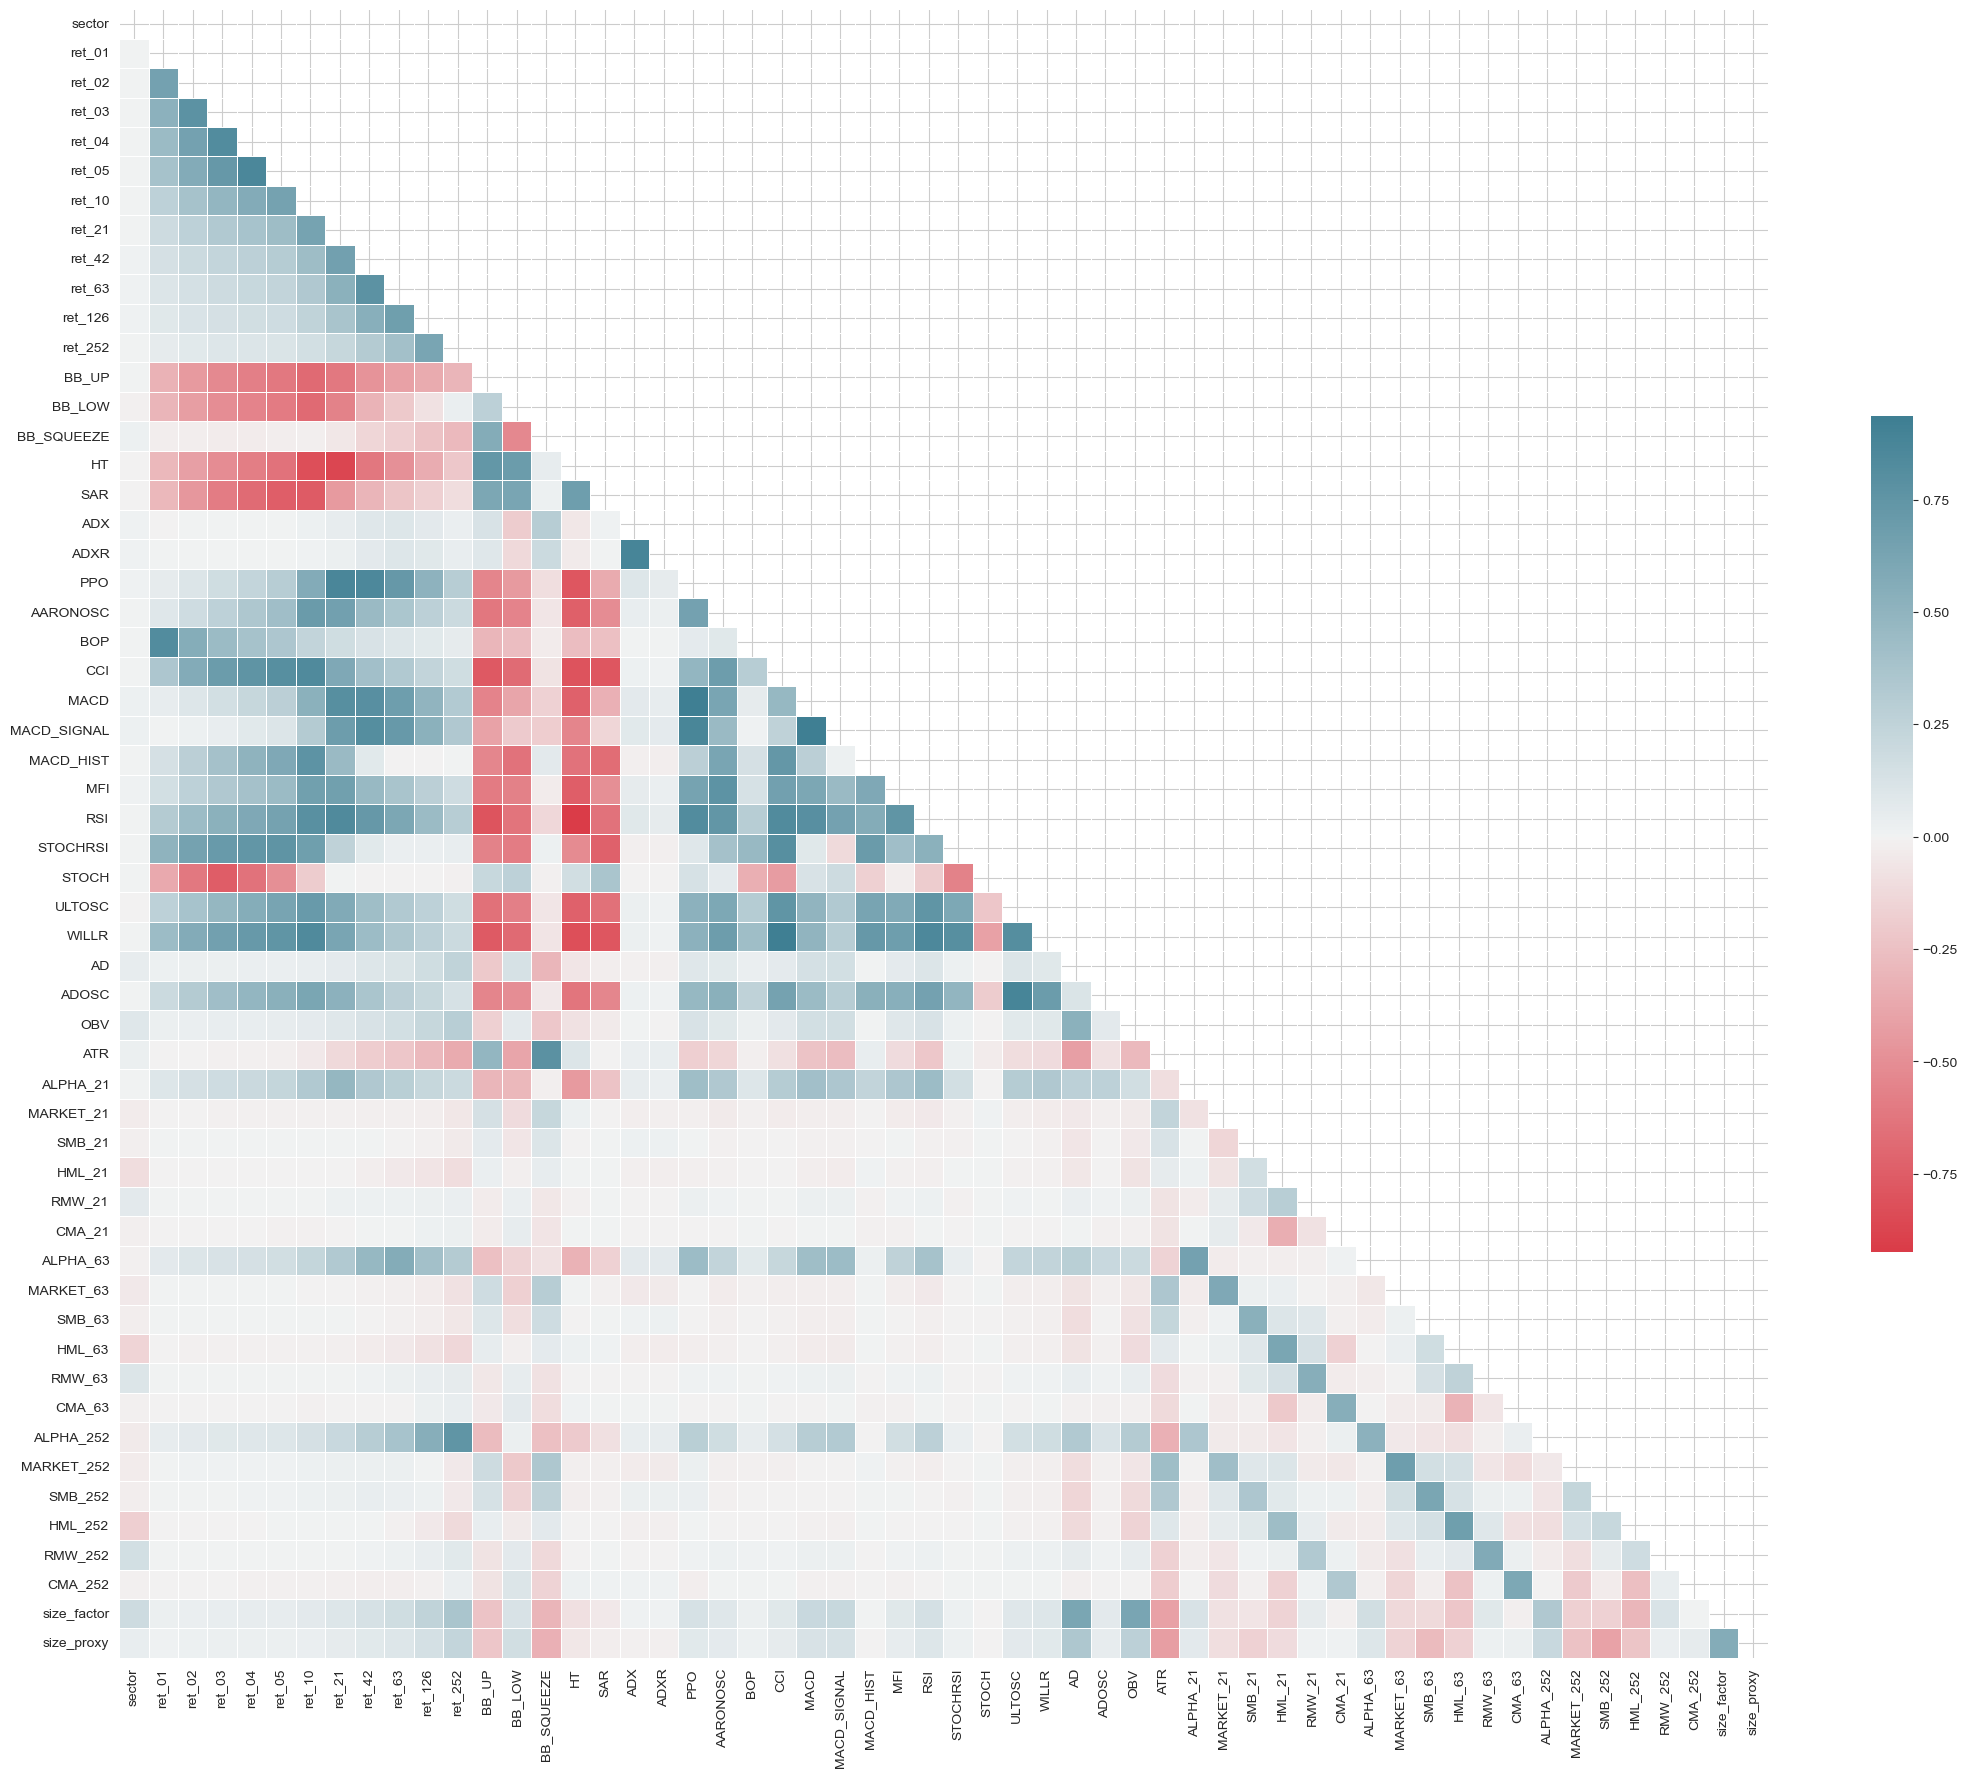

In [13]:
mask = np.triu(np.ones_like(corr_common, dtype=np.bool))
fig, ax = plt.subplots(figsize=(22, 18))
cmap = sns.diverging_palette(10, 220, as_cmap=True)

sns.heatmap(
    corr_common,
    mask=mask,
    cmap=cmap,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
)
fig.tight_layout()
fig.savefig(results_path / "factor_corr_common", dpi=300);

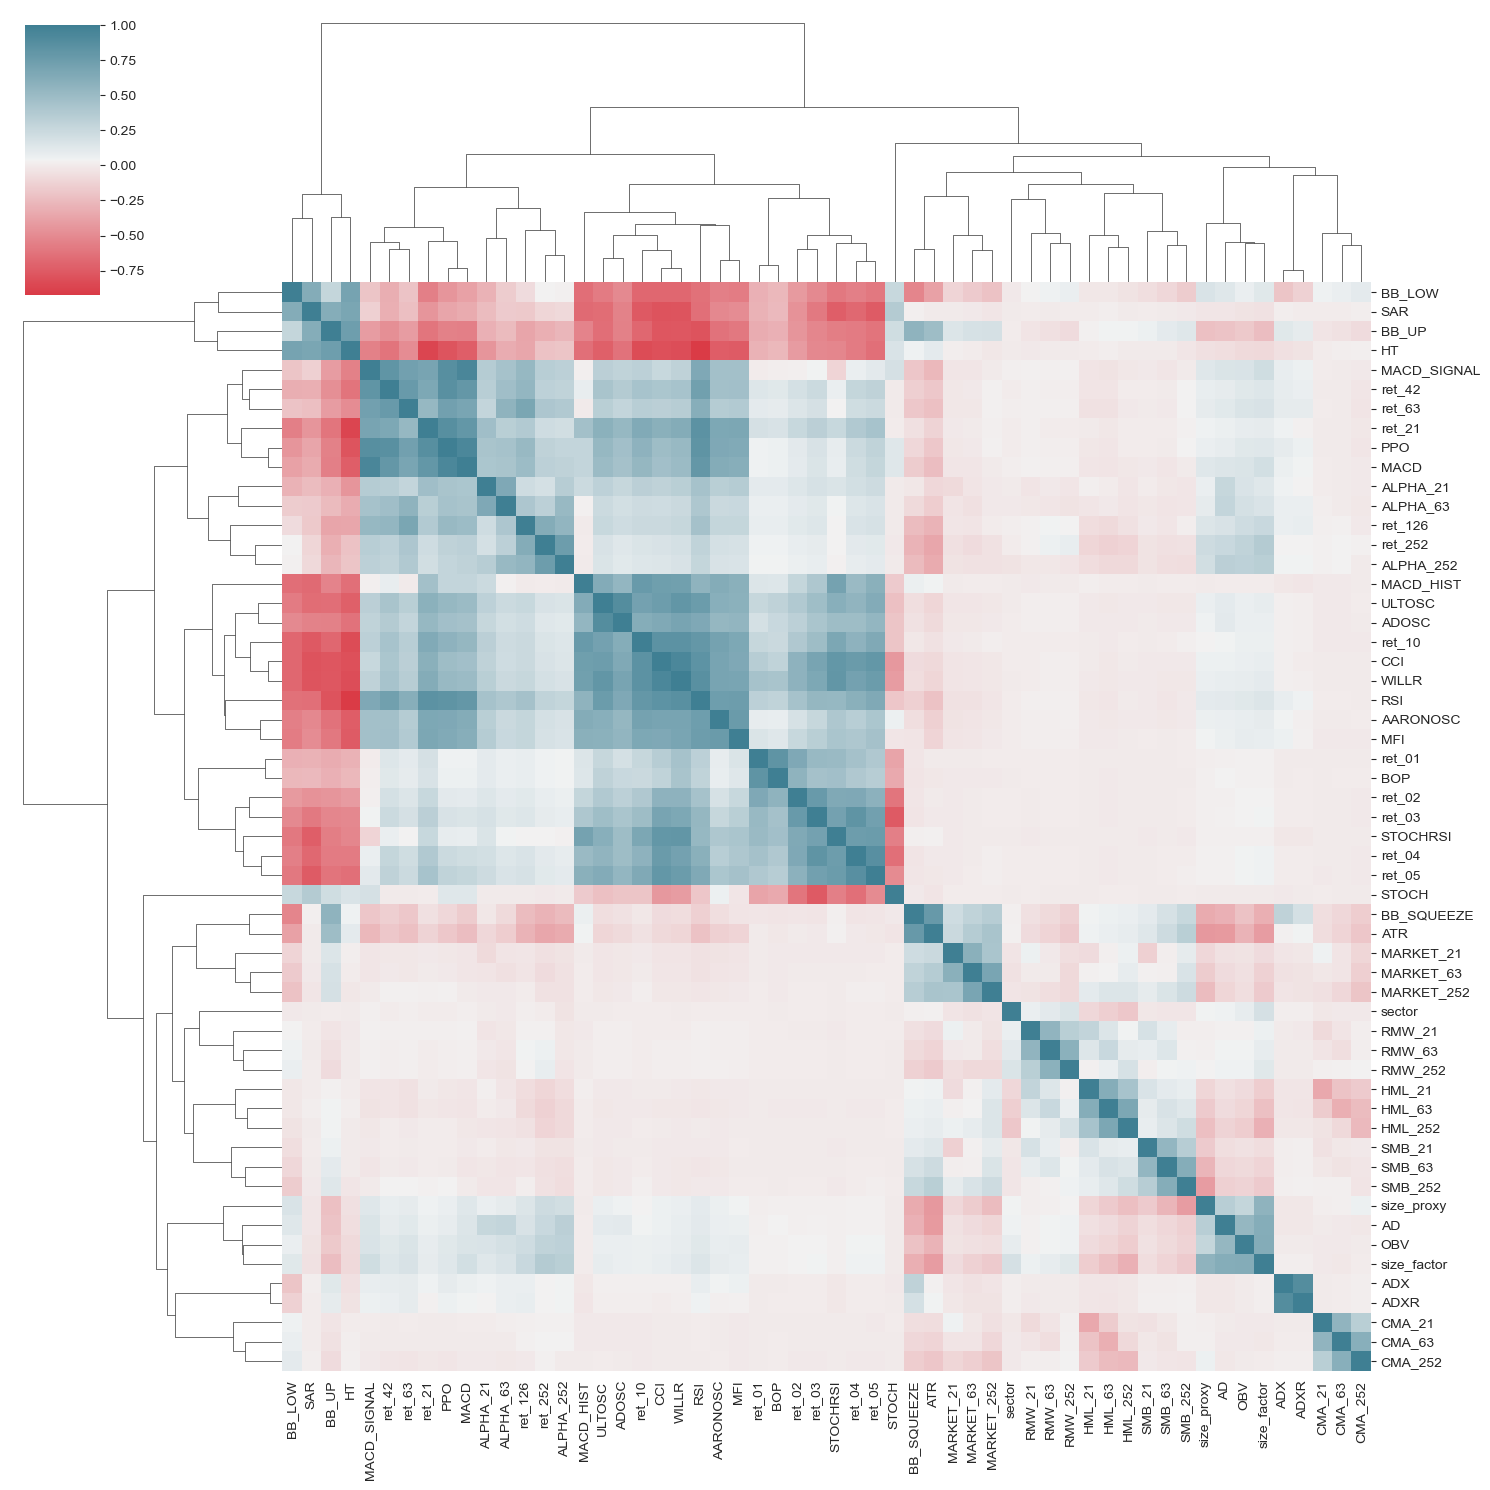

In [14]:
g = sns.clustermap(corr_common, cmap=cmap, figsize=(15, 15))
g.savefig(results_path / "factor_corr_common_cluster", dpi=300);

In [15]:
corr_ = corr_common.stack().reset_index()
corr_.columns = ["x1", "x2", "rho"]
corr_ = corr_[corr_.x1 != corr_.x2].drop_duplicates("rho")

In [17]:
pd.concat([corr_.nlargest(5, columns="rho"), corr_.nsmallest(5, columns="rho")])

,x1,x2,rho
1312,MACD,MACD_SIGNAL,0.936793
1263,CCI,WILLR,0.925544
1087,PPO,MACD,0.925282
970,ADX,ADXR,0.885166
1713,ULTOSC,ADOSC,0.881911
867,HT,RSI,-0.923566
407,ret_21,HT,-0.866342
351,ret_10,HT,-0.828103
871,HT,WILLR,-0.825403
862,HT,CCI,-0.806064


### Formulaic Alphas

In [18]:
%%time
corr_formula = (
    factors[alphas].sort_index().corr(method="spearman").dropna(how="all", axis=1)
)
corr_formula.to_hdf("data.h5", "correlation/formula")

CPU times: total: 13min 23s
Wall time: 13min 44s


In [19]:
corr_formula = corr_formula.dropna(how="all").dropna(how="all", axis=1)

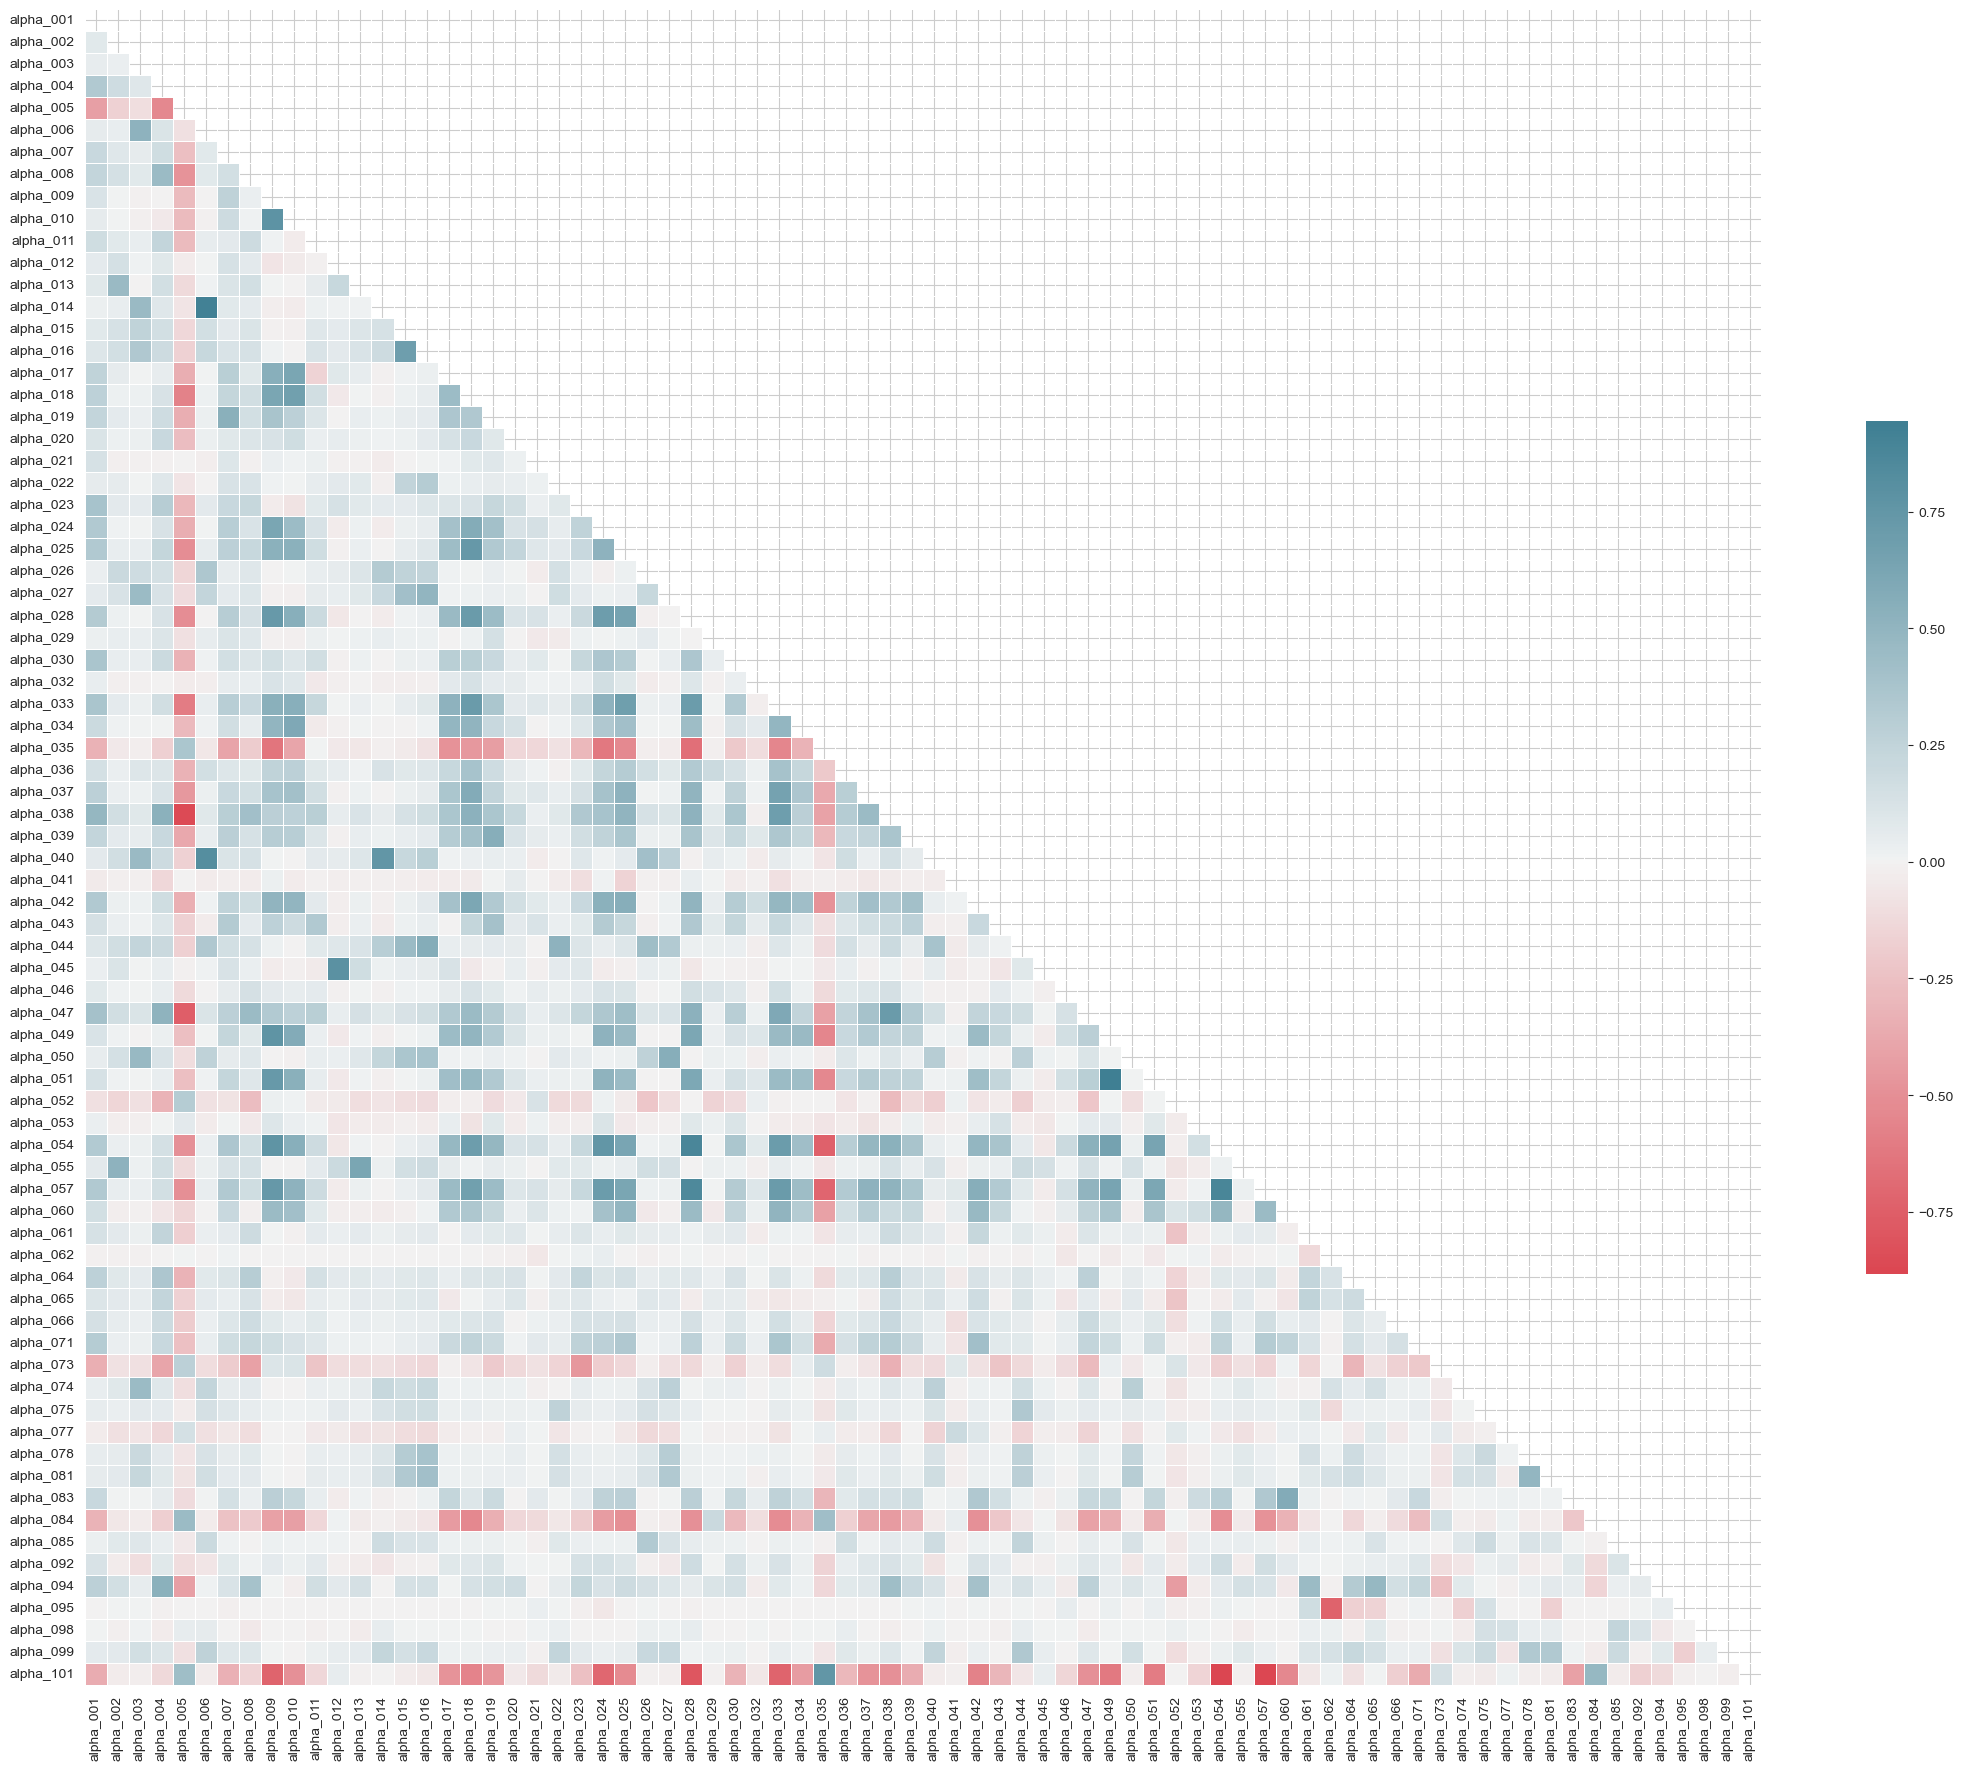

In [20]:
mask = np.triu(np.ones_like(corr_formula, dtype=np.bool))
fig, ax = plt.subplots(figsize=(22, 18))
cmap = sns.diverging_palette(10, 220, as_cmap=True)

sns.heatmap(
    corr_formula,
    mask=mask,
    cmap=cmap,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
)
fig.tight_layout()
fig.savefig(results_path / "factor_correlation_formula", dpi=300);

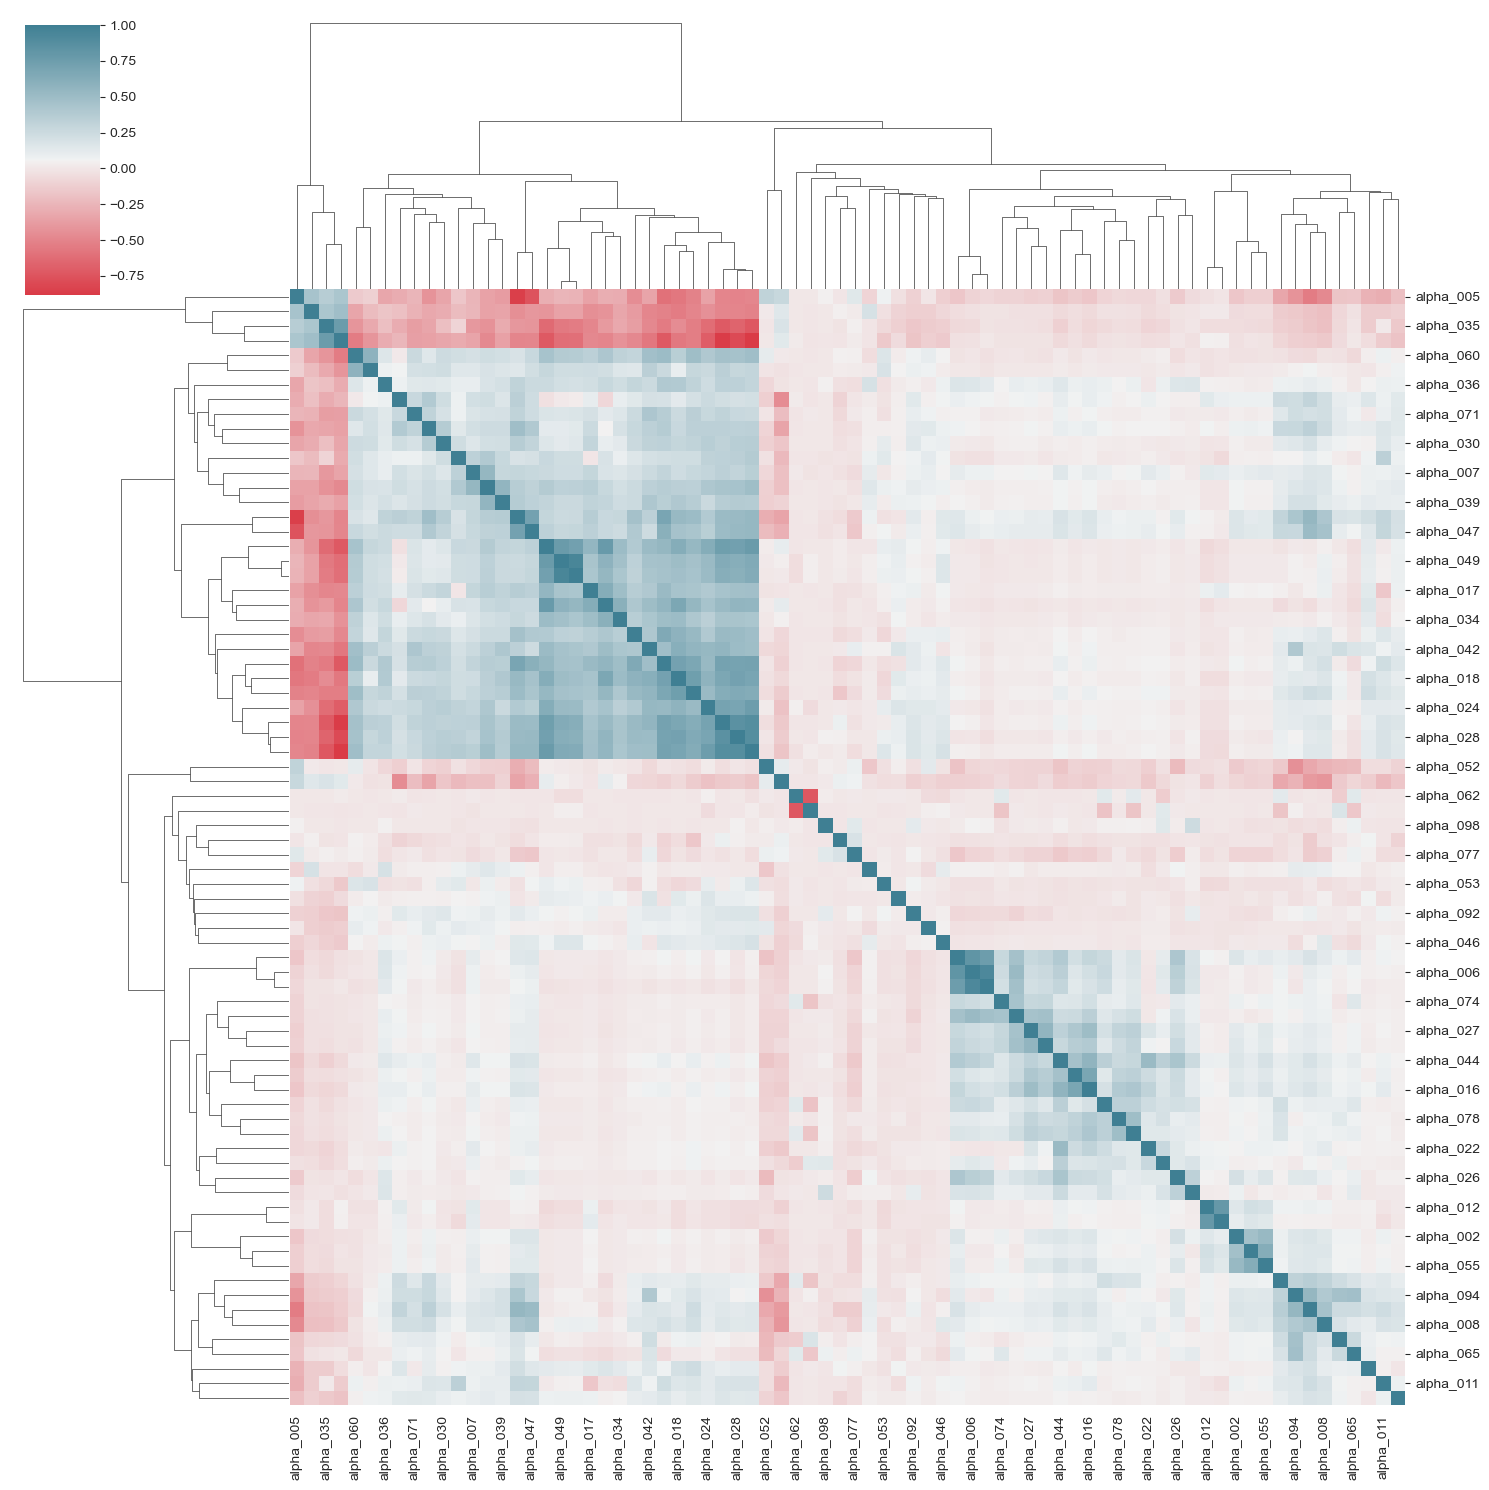

In [21]:
g = sns.clustermap(
    corr_formula.replace((np.inf, -np.inf), np.nan), cmap=cmap, figsize=(15, 15)
)
g.savefig(results_path / "factor_correlation_formula_cluster", dpi=300);

In [22]:
corr_formula_ = corr_formula.stack().reset_index()
corr_formula_.columns = ["x1", "x2", "rho"]
corr_formula_ = corr_formula_[corr_formula_.x1 != corr_formula_.x2].drop_duplicates(
    "rho"
)

In [24]:
pd.concat([corr_formula_.nlargest(5, columns="rho"), corr_formula_.nsmallest(5, columns="rho")])

,x1,x2,rho
3544,alpha_049,alpha_051,0.945057
393,alpha_006,alpha_014,0.919212
3929,alpha_054,alpha_057,0.881424
2103,alpha_028,alpha_054,0.878107
2105,alpha_028,alpha_057,0.852622
3951,alpha_054,alpha_101,-0.882689
4103,alpha_057,alpha_101,-0.869329
340,alpha_005,alpha_038,-0.855128
2127,alpha_028,alpha_101,-0.799556
349,alpha_005,alpha_047,-0.753112


### All Factors

In [25]:
corr = factors.drop(["ret_fwd", "alpha_051"], axis=1).corr()

In [26]:
corr = corr.dropna(how="all").dropna(how="all", axis=1)

In [27]:
corr.to_hdf("data.h5", "correlation/all")

In [28]:
corr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 131 entries, sector to alpha_101
Columns: 131 entries, sector to alpha_101
dtypes: float64(131)
memory usage: 135.1+ KB


In [29]:
corr.shape

(131, 131)

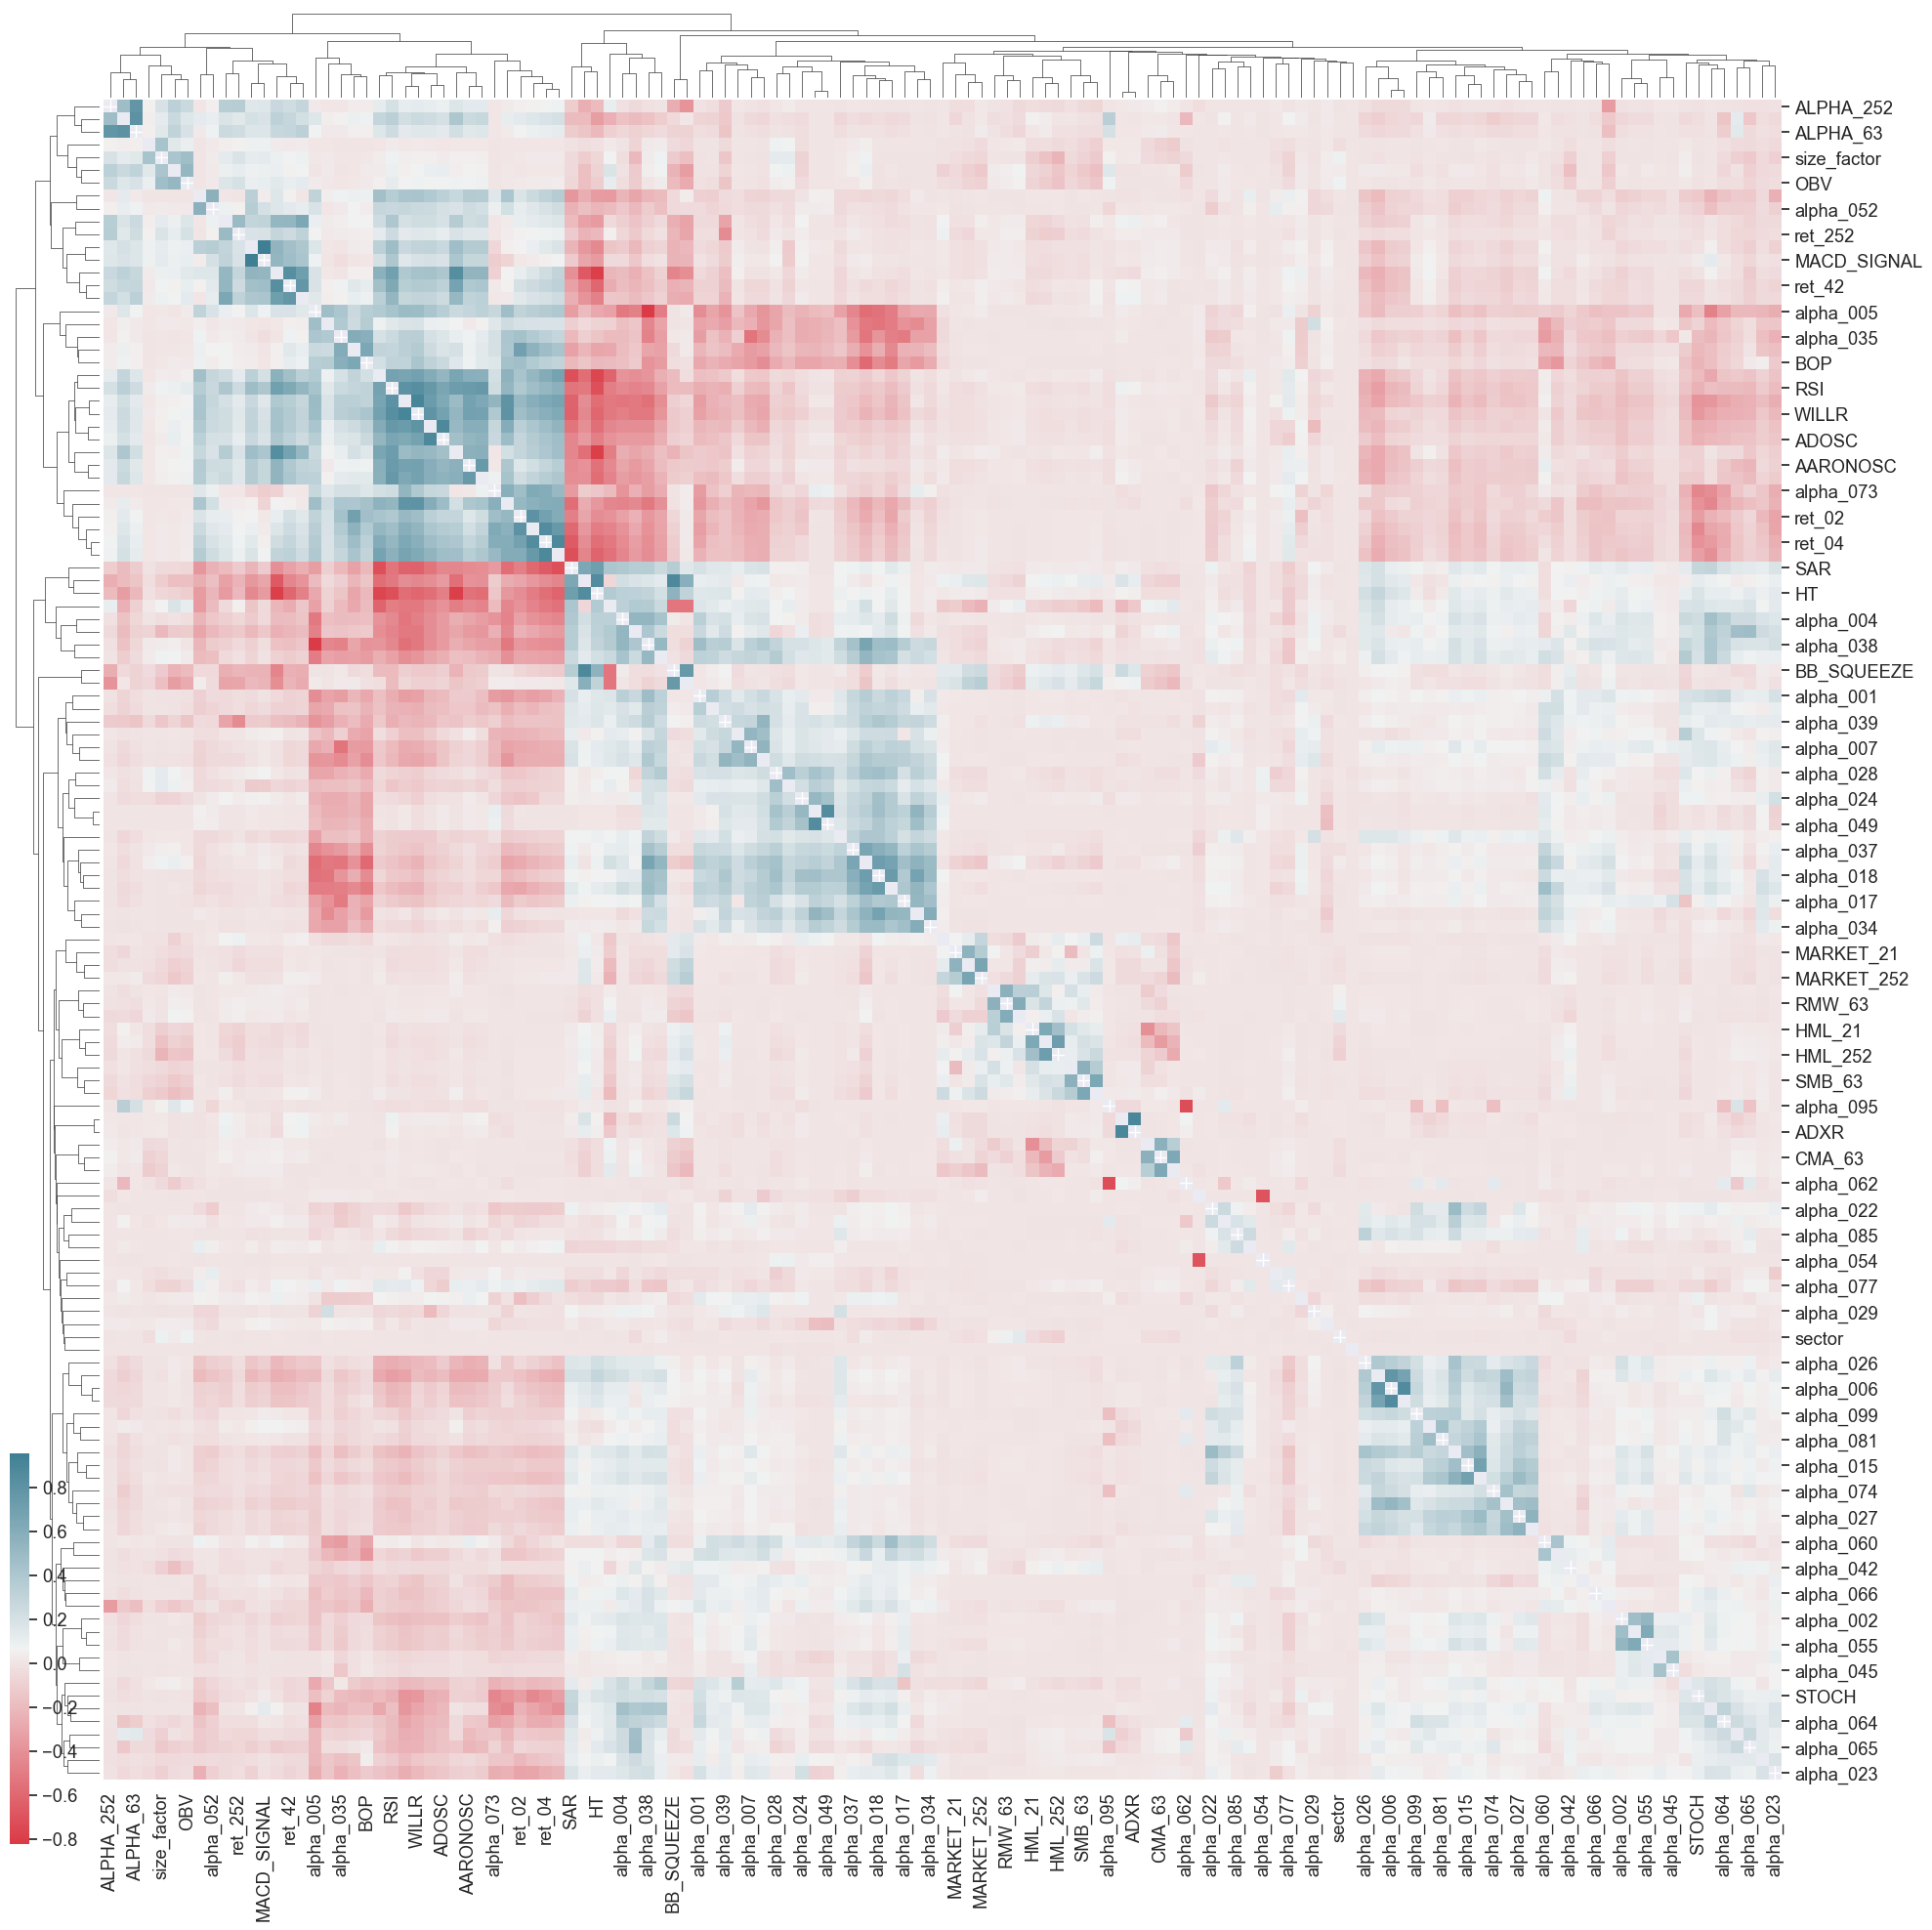

In [30]:
sns.set(font_scale=1.2)

mask = np.zeros_like(corr)
np.fill_diagonal(mask, 1)

g = sns.clustermap(
    corr,
    cmap=cmap,
    figsize=(20, 20),
    dendrogram_ratio=0.05,
    mask=mask,
    cbar_pos=(0.01, 0.05, 0.01, 0.2),
)
g.savefig(results_path / "factor_correlation_all", dpi=300);

## Forward return correlation

In [31]:
fwd_corr = factors.drop(["ret_fwd", "alpha_051"], axis=1).corrwith(
    factors.ret_fwd, method="spearman"
)

In [32]:
fwd_corr = fwd_corr.dropna()

In [33]:
fwd_corr.to_hdf("data.h5", "correlation/fwd_ret")

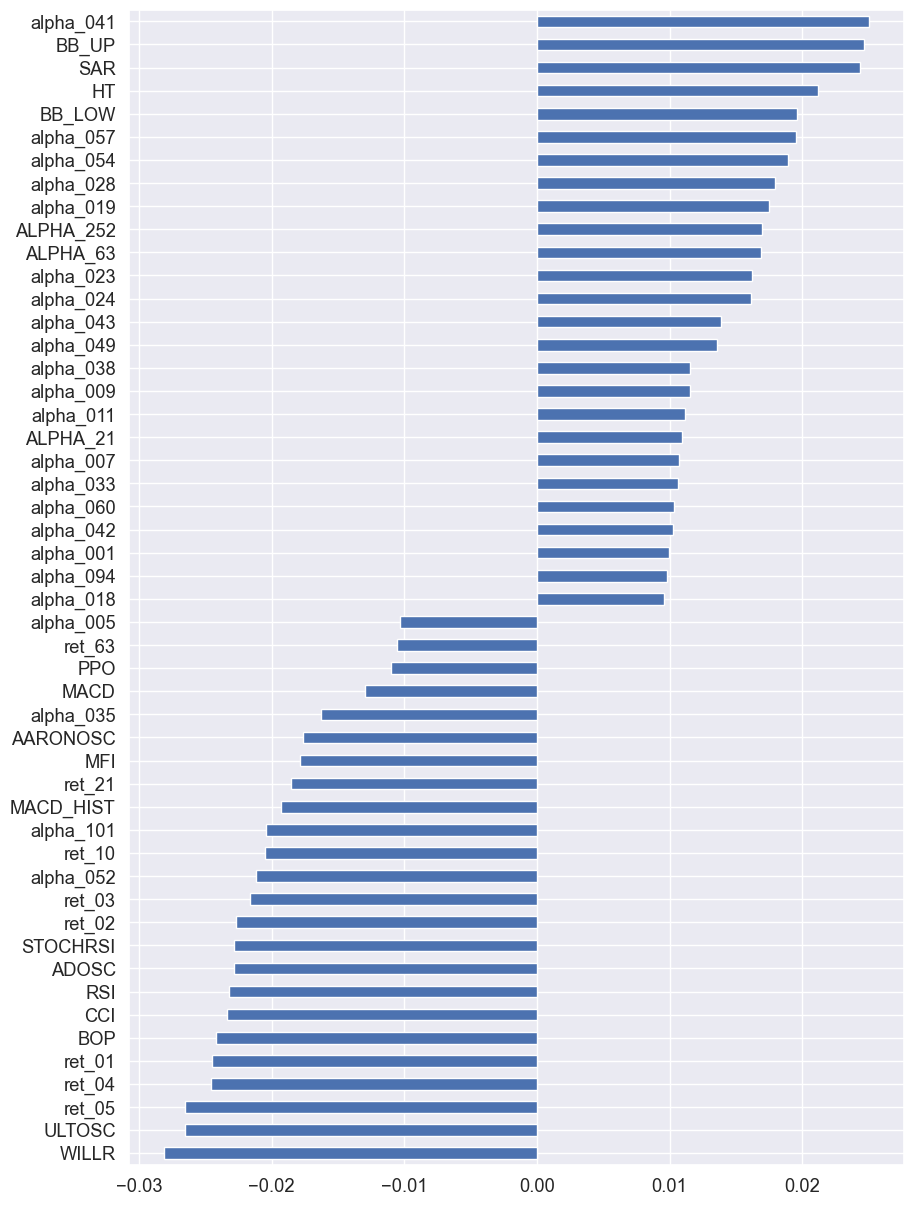

In [34]:
top50 = fwd_corr.abs().nlargest(50).index
fwd_corr.loc[top50].sort_values().plot.barh(figsize=(10, 15), legend=False);

## Mutual Information

In [35]:
mi = {}
for feature in tqdm(features):
    df = factors.loc[:, ["ret_fwd", feature]].dropna().sample(n=100000)
    discrete_features = df[feature].nunique() < 10
    mi[feature] = mutual_info_regression(
        X=df[[feature]], y=df.ret_fwd, discrete_features=discrete_features
    )[0]
mi = pd.Series(mi)

  0%|          | 0/134 [00:00<?, ?it/s]

100%|██████████| 134/134 [01:31<00:00,  1.46it/s]


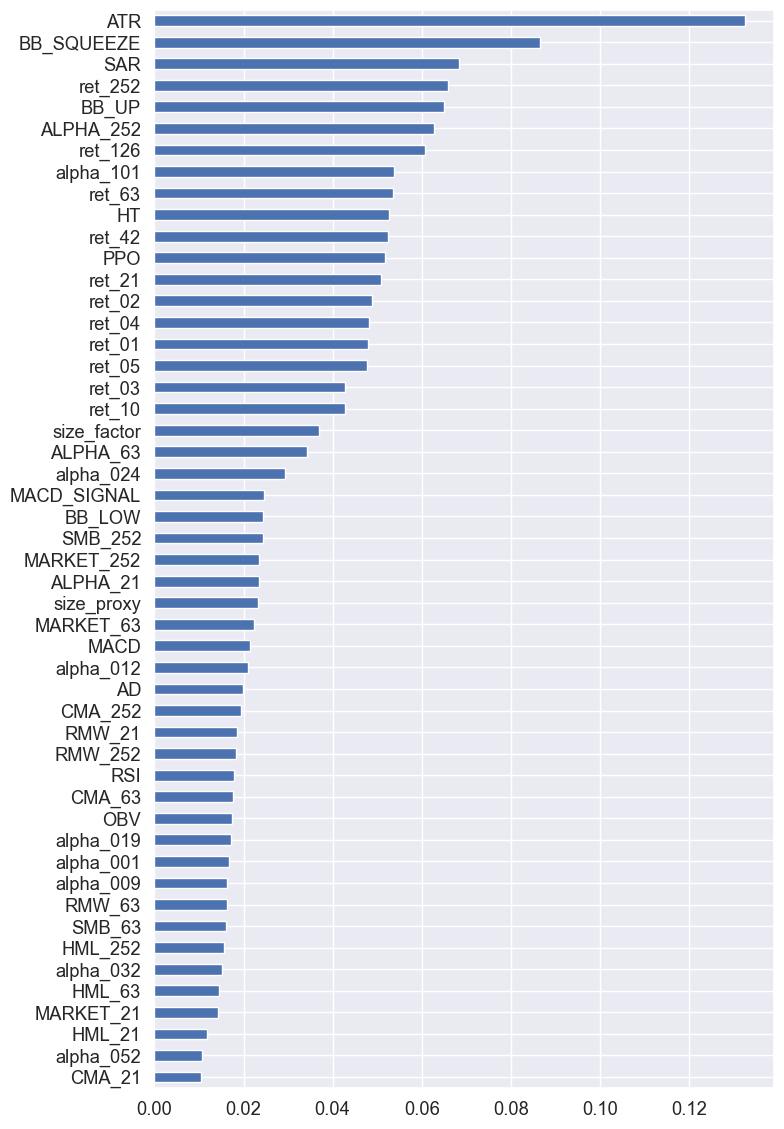

In [36]:
mi.nlargest(50).sort_values().plot.barh(figsize=(8, 14));

In [37]:
mi.to_hdf("data.h5", "mutual_information")

## LightGBM Feature Importance

In [38]:
def get_fi(model):
    fi = model.feature_importance(importance_type="gain")
    return pd.Series(fi / fi.sum(), index=model.feature_name())

In [39]:
def ic_lgbm(preds, train_data):
    """Custom IC eval metric for lightgbm"""
    is_higher_better = True
    return "ic", spearmanr(preds, train_data.get_label())[0], is_higher_better

In [40]:
uniques = factors.nunique()

In [41]:
categoricals = uniques[uniques < 20].index.tolist()

In [42]:
categoricals

['sector',
 'alpha_004',
 'alpha_021',
 'alpha_027',
 'alpha_061',
 'alpha_062',
 'alpha_064',
 'alpha_065',
 'alpha_068',
 'alpha_073',
 'alpha_074',
 'alpha_075',
 'alpha_081',
 'alpha_086',
 'alpha_092',
 'alpha_095',
 'alpha_099']

In [43]:
features = factors.columns.difference(fwd_returns).tolist()

In [44]:
label = "ret_fwd"

In [45]:
train_length = int(8.5 * 252)
test_length = 252
n_splits = 1

In [46]:
params = dict(boosting="gbdt", objective="regression", verbose=-1, metric="None")
num_boost_round = 5000

In [52]:
lgb_data = lgb.Dataset(
    data=factors.loc[:, features],
    label=factors.loc[:, label],
    categorical_feature=categoricals,
    free_raw_data=False,
)

cv = MultipleTimeSeriesCV(
    n_splits=n_splits,
    lookahead=1,
    test_period_length=test_length,
    train_period_length=train_length,
)

feature_importance, ic, daily_ic = [], [], []

for i, (train_idx, test_idx) in enumerate(cv.split(X=factors)):
    start = time()
    lgb_train = lgb_data.subset(
        used_indices=train_idx.tolist(), params=params
    ).construct()
    lgb_test = lgb_data.subset(
        used_indices=test_idx.tolist(), params=params
    ).construct()
    evals_result = {}
    model = lgb.train(
        params=params,
        train_set=lgb_train,
        num_boost_round=num_boost_round,
        valid_sets=[lgb_train, lgb_test],
        valid_names=["train", "valid"],
        feval=ic_lgbm,
        callbacks=[lgb.callback.record_evaluation(evals_result), lgb.callback.early_stopping(500)]
    )
    model.save_model("models/lgb_model.txt")
    fi = get_fi(model)
    fi.to_hdf("data.h5", f"fi/{i:02}")
    test_set = factors.iloc[test_idx, :]
    X_test = test_set.loc[:, model.feature_name()]
    y_test = test_set.loc[:, label]
    y_pred = model.predict(X_test)
    cv_preds = y_test.to_frame("y_test").assign(y_pred=y_pred)
    cv_preds.to_hdf("preds.h5", f"preds/{i:02}")

    by_day = cv_preds.groupby(level="date")
    ic_by_day = by_day.apply(lambda x: spearmanr(x.y_test, x.y_pred)[0])
    daily_ic_mean = ic_by_day.mean()
    daily_ic_median = ic_by_day.median()
    ic = spearmanr(cv_preds.y_test, cv_preds.y_pred)[0]
    print(
        f"\n{time() - start:6.1f} | {ic:6.2%} | {daily_ic_mean: 6.2%} | {daily_ic_median: 6.2%}"
    )

Training until validation scores don't improve for 500 rounds
Early stopping, best iteration is:
[119]	train's ic: 0.158343	valid's ic: 0.0162589

 183.6 |  1.63% |  1.18% |  2.03%


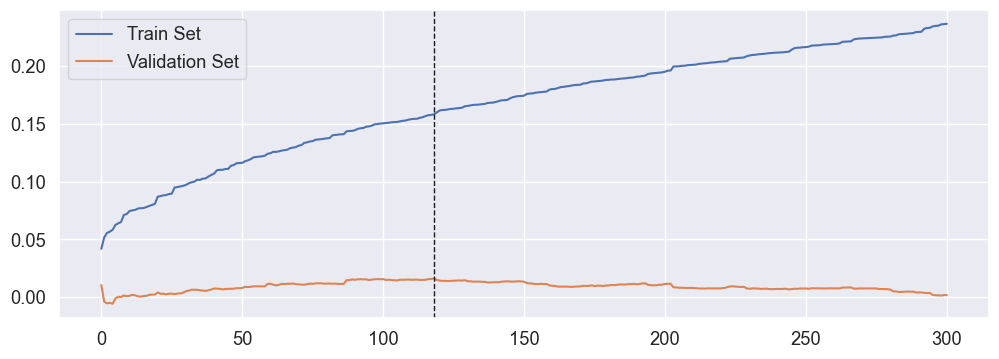

In [53]:
cv_result = pd.DataFrame(
    {
        "Train Set": evals_result["train"]["ic"],
        "Validation Set": evals_result["valid"]["ic"],
    }
)

ax = cv_result.loc[:300].plot(figsize=(12, 4))
ax.axvline(cv_result["Validation Set"].idxmax(), c="k", ls="--", lw=1);

## SHAP Values

In [54]:
shap.initjs()

In [70]:
# model = lgb.Booster(model_file='models/lgb_model.txt')

In [55]:
explainer = shap.TreeExplainer(model)

In [56]:
# workaround for SHAP version 0.30: https://github.com/slundberg/shap/issues/794
model.params["objective"] = "regression"

In [57]:
shap_values = explainer.shap_values(
    factors.iloc[train_idx, :].loc[:, model.feature_name()]
)

In [58]:
np.save("models/shap_values.npy", shap_values)

In [59]:
shap_values = np.load("models/shap_values.npy")

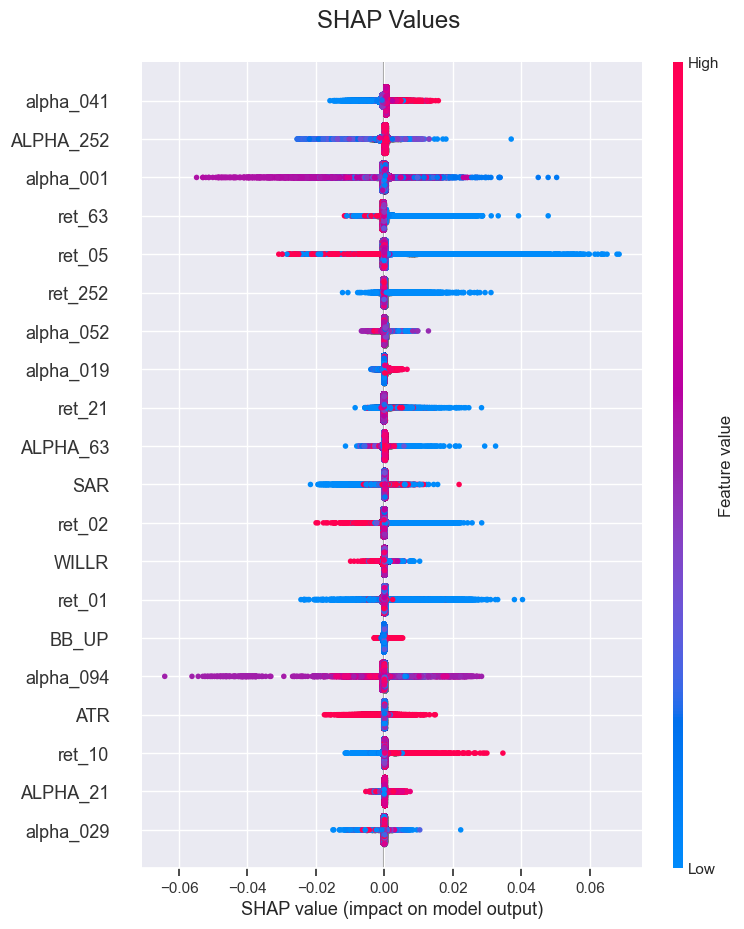

In [60]:
shap.summary_plot(
    shap_values, factors.iloc[train_idx, :].loc[:, model.feature_name()], show=False
)
plt.gcf().suptitle("SHAP Values")
plt.gcf().tight_layout()
plt.gcf().savefig(results_path / "shap_summary_dot", dpi=300)

In [61]:
shap_values = pd.DataFrame(shap_values, columns=features)

## Summary

In [62]:
mi = pd.read_hdf("data.h5", "mutual_information")
fwd_corr = pd.read_hdf("data.h5", "correlation/fwd_ret")

In [63]:
shap_summary = shap_values.abs().mean()
shap_summary /= shap_summary.sum()

In [64]:
stats = (
    mi.to_frame("Mutual Information")
    .join(fwd_corr.to_frame("Information Coefficient"))
    .join(fi.to_frame("Feature Importance"))
    .join(shap_summary.to_frame("SHAP Values"))
)

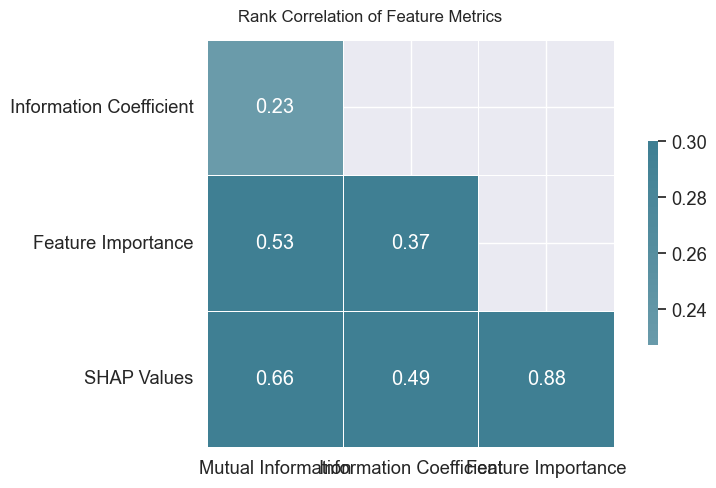

In [65]:
cols = {"Information Coefficient": stats["Information Coefficient"].abs()}
corr = stats.assign(**cols).corr("spearman")
mask = np.triu(np.ones_like(corr, dtype=np.bool))
corr = corr.iloc[1:, :-1]
mask = mask[1:, :-1]

fig, ax = plt.subplots(figsize=(8, 5))

cmap = sns.diverging_palette(10, 220, as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=0.3,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True,
    fmt=".2f",
)
plt.xticks(rotation=0)
fig.suptitle("Rank Correlation of Feature Metrics", fontsize=12)
fig.tight_layout()
fig.subplots_adjust(top=0.92)
fig.savefig(results_path / "metrics_correlation", dpi=300);

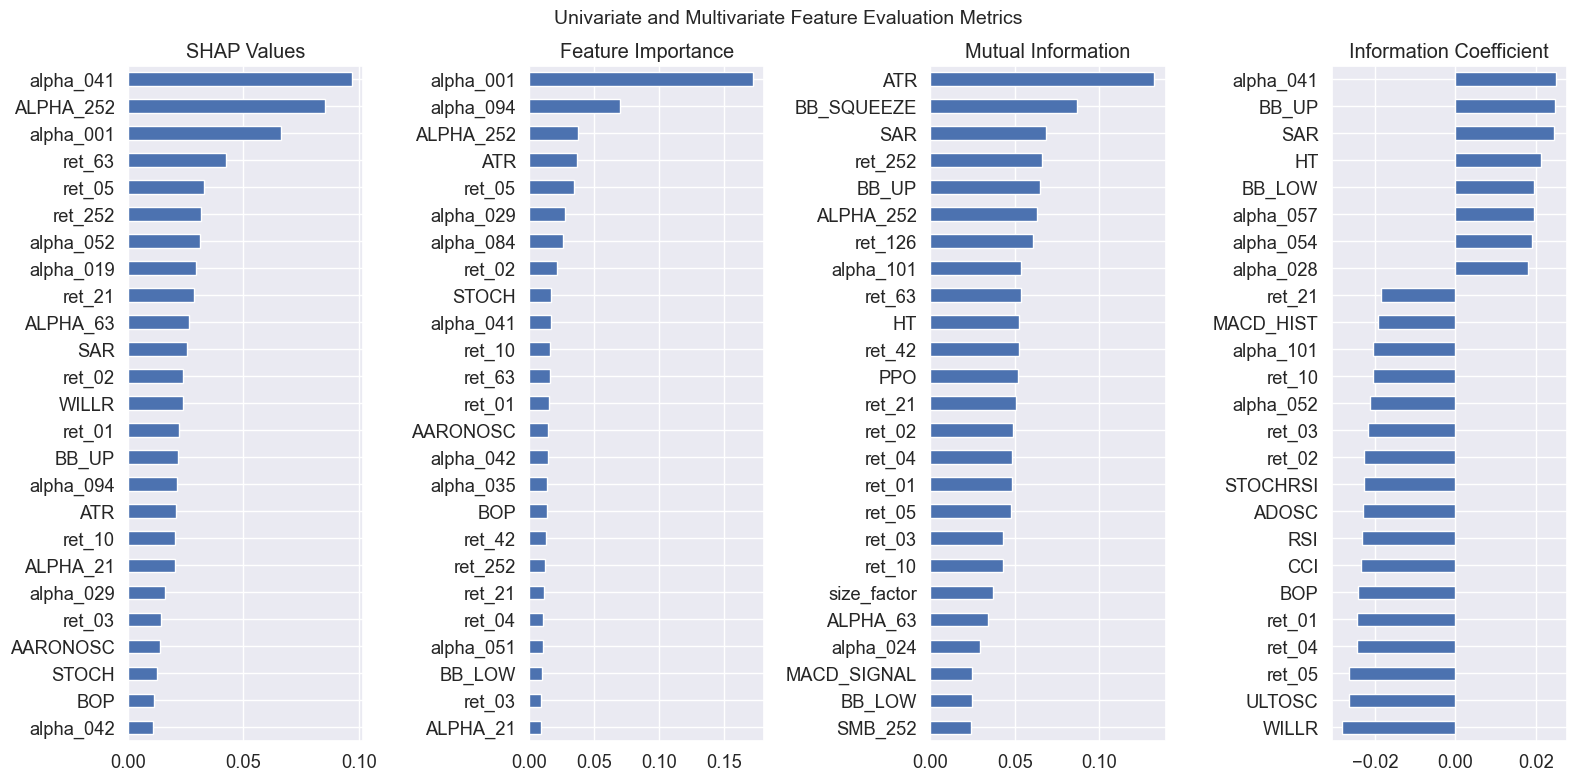

In [66]:
top_n = 25
fig, axes = plt.subplots(ncols=4, figsize=(16, 8))

shap_summary.nlargest(top_n).sort_values().plot.barh(ax=axes[0], title="SHAP Values")

fi.nlargest(top_n).sort_values().plot.barh(ax=axes[1], title="Feature Importance")

mi.nlargest(top_n).sort_values().plot.barh(ax=axes[2], title="Mutual Information")

top_corr = fwd_corr.abs().nlargest(top_n).index
fwd_corr.loc[top_corr].sort_values().plot.barh(
    ax=axes[3], title="Information Coefficient"
)

fig.suptitle("Univariate and Multivariate Feature Evaluation Metrics", fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.91)
fig.savefig(results_path / "all_feature_metrics");